In [57]:
# This is to compare theory N0, N1 with the optimal estimator and non gaussian signal. 
# Option 1 - theory N0, thoery N1, optimal estimator kkk, non gaussian signal
# Option 2 naive kkk reconstruction, optimal estimator kkk, non gaussian signal
# The point is to make it obvious how important the residual N2 bias is.

In [58]:
#!pip install camb

In [59]:
import numpy as np
import camb
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Configure Matplotlib options
from paper_plots.setup_matplotlib import *
from matplotlib.ticker import MaxNLocator

In [60]:
# Import cmblensplus for analytic bispectrum
import sys, os
sys.path.append('/home/amb257/software/cmplx_cmblensplus/wrap')
sys.path.append('/home/amb257/software/cmplx_cmblensplus/utils')
# from cmblensplus/wrap/
import basic
import curvedsky as cs
import flatsky as fs
import multiprocessing as mp

In [61]:
# Some parameters

# CMB ells
rlmin, rlmax = 2, 2000
rsample = 100 # or fully sampled: int(rlmax-rlmin+1)
l1 = np.linspace(rlmin, rlmax, rsample)

N_phi = 50 # vegas will take many more points
phi1 = np.linspace(0., 2*np.pi, N_phi) # angle between l1 and L

# Reconstruction Ls
Lmin, Lmax = 2, 2000
L = np.linspace(Lmin,Lmax+1,rsample) 

In [62]:
# We need to add the analytic PB + LSS bispectrum to the plots.

# Your existing setup
cpmodel = 'modelw'
model = 'GM'
zcmb = 1088.69
zs = [zcmb, zcmb, zcmb]
zmin, zmax = 0.0001, 40.
zn = 50
btype = 'kkk'  # Pure CMB lensing convergence
lmin = 1
lmax = 2000

# Get z points and power spectrum (your existing code)
z, dz = basic.bispec.zpoints(zmin, zmax, zn)

pars = camb.CAMBparams()
pars.set_cosmology(H0=70., ombh2=0.046*.7**2, omch2=0.233*.7**2)
pars.InitPower.set_params(ns=0.97, As=2.25e-9)
pars.set_matter_power(redshifts=[0.], kmax=24.)
results = camb.get_results(pars)
k, __, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=40, npoints=1000)


In [63]:
# Now do the signal calculation
# Equilateral configuration
bl_lss_equi, bl_pb_equi = basic.bispec.bispeclens('equi', cpmodel, model, z, dz, zs, lmin, lmax, k, pk[0], btype=btype)
bl_total_equi = bl_lss_equi + bl_pb_equi

# Folded configuration
bl_lss_fold, bl_pb_fold = basic.bispec.bispeclens('fold', cpmodel, model, z, dz, zs, lmin, lmax, k, pk[0], btype=btype)
bl_total_fold = bl_lss_fold + bl_pb_fold

# Plot - handle negative values properly
L_analytic = np.arange(lmin, lmax+1)

 compute bispectrum: shape = equi    
 compute bispectrum: shape = fold    


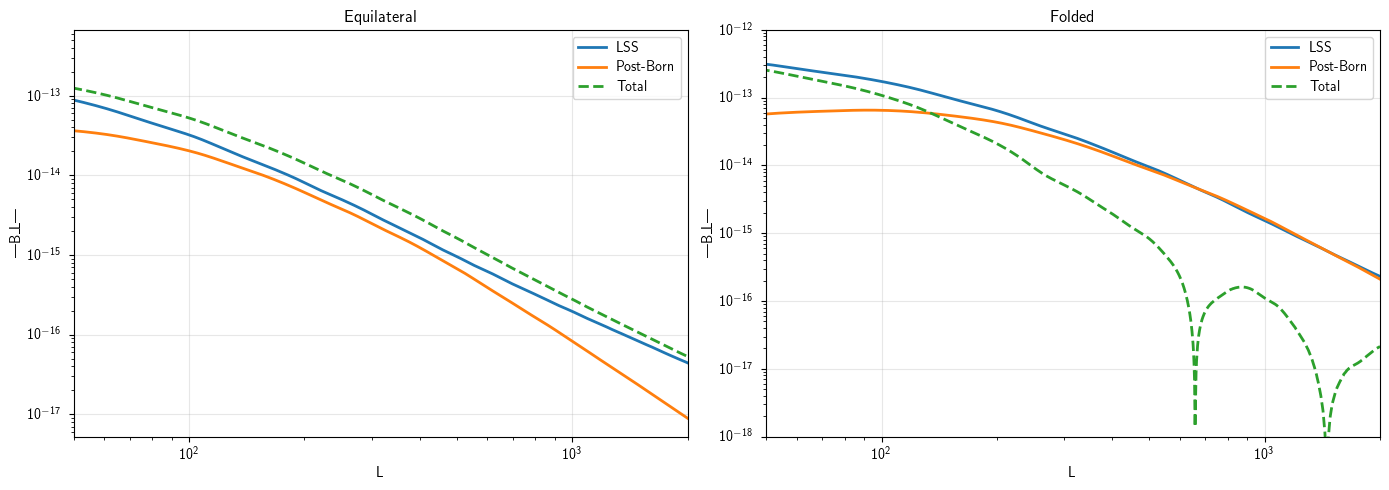

In [ ]:
# Now plot just the analytic PB +LSS bispectrum
# Note comparison with Pratten and Lewis (https://arxiv.org/pdf/1605.05662) demonstrates this is correct as is.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Equilateral - use absolute values for log scale
ax1.loglog(L_analytic, np.abs(bl_lss_equi), label='LSS', linewidth=2)
ax1.loglog(L_analytic, np.abs(bl_pb_equi), label='Post-Born', linewidth=2)
ax1.loglog(L_analytic, np.abs(bl_total_equi), label='Total', linewidth=2, linestyle='--')
ax1.set_xlabel('L')
ax1.set_ylabel('|B_L|')
ax1.set_title('Equilateral')
ax1.set_xlim([50, 2000])
ax2.set_ylim([1e-18, 1e-12])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Folded - for folded configuration, the output is at L, L/2, L/2
# So we only get non-zero values at even L
# Find non-zero elements to determine actual L values
nonzero_fold = np.abs(bl_lss_fold) > 1e-30  # Small threshold to avoid numerical zeros
L_fold_actual = L_analytic[nonzero_fold]

ax2.loglog(L_fold_actual, np.abs(bl_lss_fold[nonzero_fold]), label='LSS', linewidth=2)
ax2.loglog(L_fold_actual, np.abs(bl_pb_fold[nonzero_fold]), label='Post-Born', linewidth=2)
ax2.loglog(L_fold_actual, np.abs(bl_total_fold[nonzero_fold]), label='Total', linewidth=2, linestyle='--')
ax2.set_xlabel('L')
ax2.set_ylabel('|B_L|')
ax2.set_title('Folded')
ax2.set_xlim([50, 2000])
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
# First import all the data
# Alba's theory curves:
_, n0_equil = np.loadtxt('/home/amb257/kappa_bispec/alba_2023/CMBlens_bispectrum_noisebiases/output/2Nov_N0equil_rlmax3000Lmax3000_lCl_lCl_lCl.txt', unpack = True)
_, n1sep_equil = np.loadtxt('/home/amb257/kappa_bispec/CMBlens_bispectrum_noisebiases/output/sepN1equil_rlmax2000Lmax2000_gCl_lCl_lCl.txt', unpack = True)
_, n1cpl_equil = np.loadtxt('/home/amb257/kappa_bispec/CMBlens_bispectrum_noisebiases/output/coupN1equil_rlmax2000Lmax2000_gCl_lCl_lCl.txt', unpack = True)
L_N1_eq, N1_equi_rkmax3k = np.loadtxt("/home/amb257/kappa_bispec/alba_code/kappa_bispec_noisebiases/ALBA_CL_N1_EQUI_5_10_25.txt", unpack='True')
L_N1_fld, N1_fold_rlmax3k = np.loadtxt("/home/amb257/kappa_bispec/alba_code/kappa_bispec_noisebiases/ALBA_CL_N1_FOLD_5_10_25.txt", unpack='True')

#Folded N0 numerical
fold_L_N0_num = np.load("/home/amb257/kappa_bispec/bispec_opt_est/N0_numerical/N0_numerical_BATCHvegas/rlmax3k_FOLD_L_N0_num.npy")
N0_numerical_fold = np.load("/home/amb257/kappa_bispec/bispec_opt_est/N0_numerical/N0_numerical_BATCHvegas/rlmax3k_FOLD_N0_numerical.npy")

#Equilateral N0 numerical
equi_L_N0_num = np.load("/home/amb257/kappa_bispec/bispec_opt_est/N0_numerical/N0_numerical_BATCHvegas/rlmax3k_EQUI_L_N0_num.npy")
N0_numerical_equi = np.load("/home/amb257/kappa_bispec/bispec_opt_est/N0_numerical/N0_numerical_BATCHvegas/rlmax3k_EQUI_N0_numerical.npy")

# Optimal estimator results
L_sim, equi_opt_est, equi_err_mean = np.loadtxt('/home/amb257/kappa_bispec/bispec_opt_est/N2_numerical/opt_est_results/equilateral_opt_est.txt')
L_sim, fold_opt_est, fold_err_mean = np.loadtxt('/home/amb257/kappa_bispec/bispec_opt_est/N2_numerical/opt_est_results/folded_opt_est.txt')

# Own N2 theory results (approximation)
L_equi_lowL_approx, N2_equi_low_L_kappa_fromfull = np.loadtxt('/home/amb257/kappa_bispec/bispec_opt_est/N2_numerical/Binning_effects/outputs/equilN2_from_full_int.txt')
L_fold_lowL_approx, N2_fold_low_L_kappa_fromfull = np.loadtxt('/home/amb257/kappa_bispec/bispec_opt_est/N2_numerical/Binning_effects/outputs/foldN2_from_full_int.txt')

# Optimal estimator simulation results
L_eq, eq_opt_est, err_eq = np.loadtxt('/home/amb257/kappa_bispec/bispec_opt_est/N2_numerical/opt_est_results/equilateral_opt_est.txt')
L_fd, fd_opt_est, err_fd = np.loadtxt('/home/amb257/kappa_bispec/bispec_opt_est/N2_numerical/opt_est_results/folded_opt_est.txt')


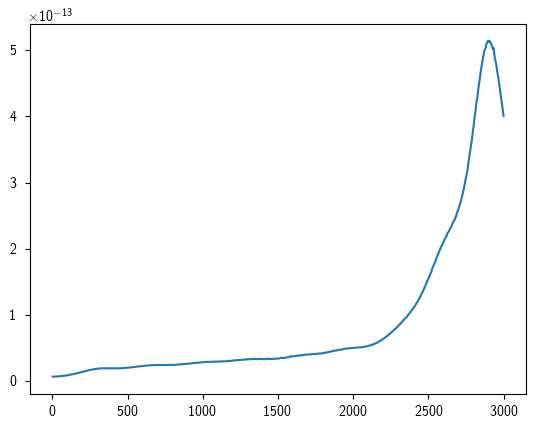

In [66]:
# convert to kappa
N0_kfactor = equi_L_N0_num**2/2
plt.plot(equi_L_N0_num, N0_kfactor**3*N0_numerical_equi)

In [67]:
from scipy.ndimage import gaussian_filter1d

# Smooth everything first
smoothed_all = gaussian_filter1d(N0_numerical_fold, sigma=1.5)

# Start with original data
N0_numerical_fold_smooth = N0_numerical_fold.copy()

# Gradually blend from original to smoothed over ~10 points
transition_start = 18
transition_length = 10
for i in range(transition_length):
    weight = i / transition_length  # 0 to 1
    idx = transition_start + i
    if idx < len(N0_numerical_fold):
        N0_numerical_fold_smooth[idx] = (1-weight) * N0_numerical_fold[idx] + weight * smoothed_all[idx]

# Fully smoothed after transition
N0_numerical_fold_smooth[transition_start + transition_length:] = smoothed_all[transition_start + transition_length:]

In [68]:
# convert to kappa
kfactor = L**2/2

/home/amb257/jupyter_kernel_plots/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.


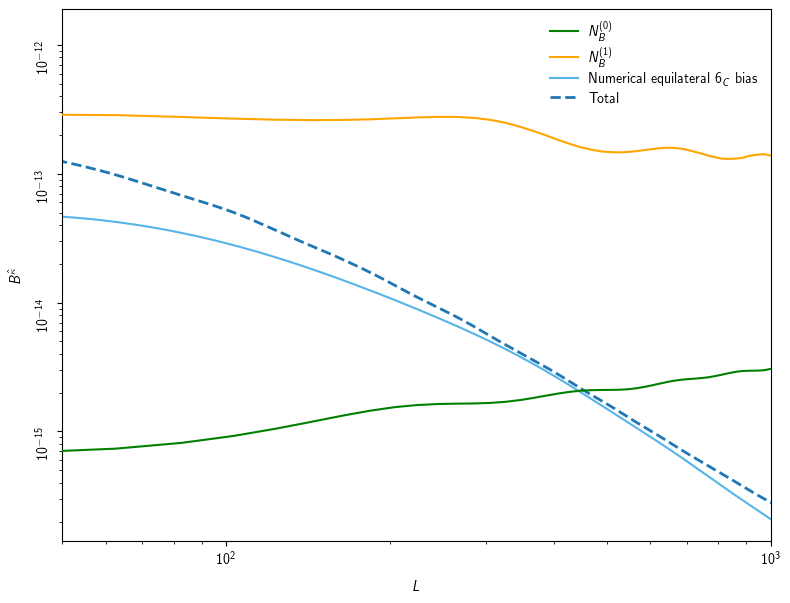

In [69]:
for width in [18.,]:

    fig = plt.figure(figsize=(cm2inch(width), cm2inch(width*6/8.)))
    # this should be changed for making a panel of multiple figures
    ax = fig.add_subplot(111)

    zeros = np.zeros(13)
    plt.plot(L, kfactor**3*n0_equil, label = '$N^{(0)}_B$', color = 'green', zorder = 10)
    plt.plot(L, kfactor**3*(n1sep_equil+n1cpl_equil), label = '$N^{(1)}_B$', color = 'orange' , zorder = 10)
    plt.plot(L_equi_lowL_approx, -1*N2_equi_low_L_kappa_fromfull, '#56b4e9', label = r'Numerical equilateral $6_C$ bias')
    #plt.errorbar(L_eq, eq_opt_est, yerr=err_eq,  color='orange', fmt='o', label="Equilateral optimal estimator", markersize=5)
    plt.plot(L_analytic[0:1000], np.abs(bl_total_equi[0:1000]), label='Total', linewidth=2, linestyle='--')
    plt.yscale('log')
    plt.xscale('log')
    # Now optimal estimator result
    #plt.errorbar(L_sim, equi_opt_est,yerr = equi_err_mean, color='orange', fmt='o', label="Equilateral optimal estimator", markersize=5)
    # x axis
    plt.hlines(0, 0, 000)
    plt.xlim([50, 1000])
    plt.ylim(0,1.9e-12)
    # legend
    leg = plt.legend(frameon=True)
    # remove box around legend
    leg.get_frame().set_edgecolor("white")
    leg.get_frame().set_alpha(.8)

    # labels
    plt.xlabel(r"$L$"); plt.ylabel(r'$B^{\hat{\kappa}}$')
    ax.yaxis.labelpad = 10*width/17.; ax.xaxis.labelpad = 10*width/17. # distance of axis label to tick labels

    # reduce ticks for small figures
    if width < 10:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # grid
    #plt.grid(True, which="major", axis="both")

    # reduce white space around figure
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # set vertical y axis ticklables
    for ticklabel in ax.yaxis.get_ticklabels():
        ticklabel.set_rotation("vertical")

    # save to pdf with right bounding box
    plt.savefig(f"/home/amb257/kappa_bispec/bispec_opt_est/Plots/paper_plots/figures/comparison_theory_{int(width*10)}.pdf", bbox_inches='tight', pad_inches=0.02)

#plt.title('Equilateral slicing', fontsize=20)



/home/amb257/jupyter_kernel_plots/lib/python3.7/site-packages/ipykernel_launcher.py:29: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.


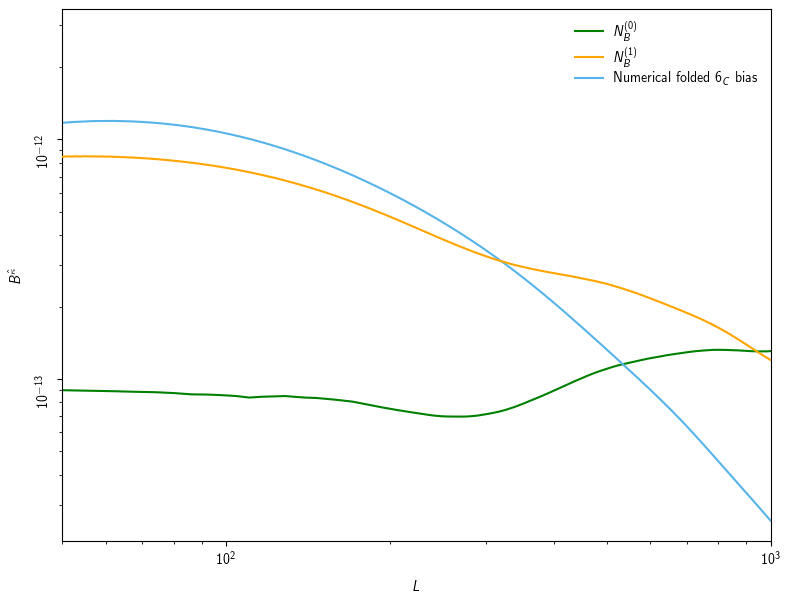

In [70]:
# Load in folded N1
L_N1, N1 = np.loadtxt('/home/amb257/kappa_bispec/alba_code/kappa_bispec_noisebiases/N1_FOLD_1_9_25.txt', unpack=True)

# convert to kappa
kappa_factor_L = L_N1_fld**2/2
kappa_factor_Lhalf = (L_N1_fld/2)**2 /2

kappa_factor_folded_bispec = kappa_factor_L*kappa_factor_Lhalf*kappa_factor_Lhalf

for width in [18.,]:

    fig = plt.figure(figsize=(cm2inch(width), cm2inch(width*6/8.)))
    # this should be changed for making a panel of multiple figures
    ax = fig.add_subplot(111)

    zeros = np.zeros(13)
    plt.plot(fold_L_N0_num, -1/128 * fold_L_N0_num**6 * N0_numerical_fold_smooth, label='$N^{(0)}_B$', color = 'green')
    plt.plot(L_N1_fld, -1*kappa_factor_folded_bispec*N1_fold_rlmax3k, label = '$N^{(1)}_B$', color = 'orange' , zorder = 10)
    plt.plot(L_fold_lowL_approx, N2_fold_low_L_kappa_fromfull, '#56b4e9', label = r'Numerical folded $6_C$ bias')
    #plt.plot(L_N0_fold_alba, 1/128 * L_N0_fold_alba**6 * fold_N0_alba, label = r'Numerical folded $N^{(0)}_B$ alba')
    plt.yscale('log')
    plt.xscale('log')
    #plt.errorbar(L_fd, -1*fd_opt_est, yerr=err_fd,  color='orange', fmt='o', label="Equilateral optimal estimator", markersize=5)
    # Now optimal estimator result
    #plt.errorbar(L_sim, equi_opt_est,yerr = equi_err_mean, color='orange', fmt='o', label="Equilateral optimal estimator", markersize=5)
    # x axis
    plt.hlines(0, 0, 1000)
    plt.xlim([50, 1000])
    plt.ylim(0,0.35e-11)
    # legend
    leg = plt.legend(frameon=True)
    # remove box around legend
    leg.get_frame().set_edgecolor("white")
    leg.get_frame().set_alpha(.8)

    # labels
    plt.xlabel(r"$L$"); plt.ylabel(r'$B^{\hat{\kappa}}$')
    ax.yaxis.labelpad = 10*width/17.; ax.xaxis.labelpad = 10*width/17. # distance of axis label to tick labels

    # reduce ticks for small figures
    if width < 10:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # grid
    #plt.grid(True, which="major", axis="both")

    # reduce white space around figure
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # set vertical y axis ticklables
    for ticklabel in ax.yaxis.get_ticklabels():
        ticklabel.set_rotation("vertical")

    # save to pdf with right bounding box
    plt.savefig(f"/home/amb257/kappa_bispec/bispec_opt_est/Plots/paper_plots/figures/comparison_theory_{int(width*10)}.pdf", bbox_inches='tight', pad_inches=0.02)


combined [2.12721711e-14 5.17460057e-14 6.75446476e-14 7.63026862e-14
 8.12704370e-14 8.39927330e-14 8.53283577e-14 8.57142705e-14
 8.54385668e-14 8.48809366e-14 8.39950220e-14 8.31337649e-14
 8.20820881e-14 8.10049919e-14 7.99465628e-14 7.88775058e-14
 7.78953922e-14 7.70916954e-14 7.61863694e-14 7.51794201e-14
 7.45641538e-14 7.39525286e-14 7.33062174e-14 7.25690184e-14
 7.20502940e-14 7.16474064e-14 7.12278177e-14 7.07413565e-14
 7.04817701e-14 6.99978805e-14 6.98095309e-14 6.95746139e-14
 6.92509562e-14 6.91197139e-14 6.88868384e-14 6.85015486e-14
 6.83057778e-14 6.81952213e-14 6.77497478e-14 6.75736669e-14
 6.72054445e-14 6.68732152e-14 6.65577325e-14 6.61361053e-14
 6.58965200e-14 6.53824637e-14 6.49758804e-14 6.44074745e-14
 6.39766528e-14 6.33644869e-14 6.28552433e-14 6.22996448e-14
 6.16082973e-14 6.09714526e-14 6.03917999e-14 5.96884688e-14
 5.89430691e-14 5.82280093e-14 5.75772936e-14 5.68745758e-14
 5.61495076e-14 5.54920136e-14 5.47693950e-14 5.41874232e-14
 5.35386278e-14

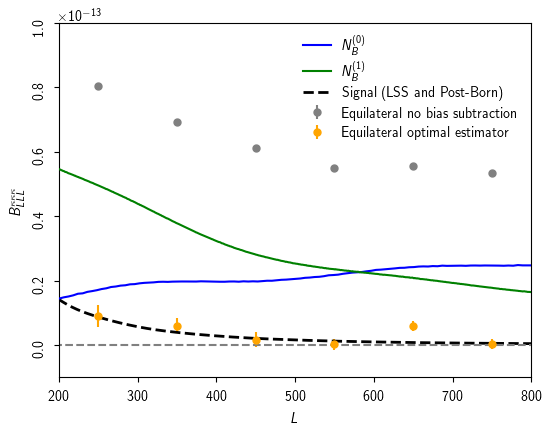

In [95]:
# Load in the naive bispectrum equilateral
# Some notes to refresh memory: this naive bispec was calculated using the noisy lensed temperature map. The code is no_RD_removal_bsp.py 
# Worry is that  while it's larger than the one with RD bias removed it is smaller than N0, N1. 
# I think it should include N0, N1 
# I've repeated with the simulations used in chapter 2 and found it does not change - is larger than the RD bispec but not large enough to include N0, N1
# Possibilities are that N0, N1 are somehow incorrect. They're noise dependent so perhaps need to change the noise. Looking at the code that generates these though
# It looks likenoise is included
# Update!!! it turns out to be a difference in rlmax. When changed rlmax to 2k instead of 3k it agreed with the numerical results. 
# # Am now rerunning the numerical results with rlmax of 3k which is what we've used for the simulation results. 
# Also keep an eye on mixing and matching equi and folded stuff.
# I have rerun N0_numerical.py from here /home/amb257/kappa_bispec/bispec_opt_est/N0_numerical with rlmax =  3k
# I am rerunning N1 this is here /home/amb257/kappa_bispec/alba_code/kappa_bispec_noisebiases/get_N1ppp.py
# Note above for equilateral uses N1 from somewhere else as was already computed but this is the only working one.
# Ok further update I've changed rlmax in the numerical N1 calculation to 3k and computed that. I now get something that is a bit smaller but still too large.
# N1 has only reduced at large l - is this expected? perhaps the problem is using Alba's cls? or the gltt stuff?
# Still waiting on N0 to complete. 
# Sorted! there was a problem in the N1 numerical where not all of the cl's had been changed to rlmax some were stuck on 2k still (rlmax vs Lmax)
# Now going to make N1_fold with rlmax 3k
# Done this, note in the above theoretical curves all N1s are for rlmax3k now but N0's are not correct yet (much slower code) so they're not correct yet
# latest news - the run of N0 didnt work because inside the compute for L function everything is hardcoded for folded triangles. Working to check folded now.
L_naive, B_naive, err_naive_B = np.loadtxt("/home/amb257/rds/hpc-work/kappa_bispec/bias_from_sims/no_RD_bispec/equi/average/naive_Bispec.txt")
L_naive_oldsim, B_naive_oldsim = np.loadtxt("/home/amb257/rds/hpc-work/kappa_bispec/bias_from_sims/no_RD_bispec/equi/ch2sims_0.txt")

factor_N1_eq = L_N1_eq**2/2
kappafactorN1eq = factor_N1_eq **3 

factor_N0_eq = equi_L_N0_num**2/2

for width in [12.,]:

    fig = plt.figure(figsize=(cm2inch(width), cm2inch(width*6/8.)))
    # this should be changed for making a panel of multiple figures
    ax = fig.add_subplot(111)
    from scipy.interpolate import interp1d

    # interpolate n1 so cn add to n0 and check
    N1_interp = interp1d(L_N1_eq, kappafactorN1eq * N1_equi_rkmax3k, kind='linear', bounds_error=False, fill_value=0)
    # Evaluate N1 at the L points (same x-axis as N0)
    N1_at_L = N1_interp(equi_L_N0_num)

    # Now you can add them together
    combined = N0_kfactor**3*N0_numerical_equi + N1_at_L
    print('combined', combined)

    # Plot the combined result
    #plt.plot(equi_L_N0_num, combined, label='$N^{(0)}_B + N^{(1)}_B$', ls='--')

    zeros = np.zeros(13)
    plt.plot(equi_L_N0_num, N0_kfactor**3*N0_numerical_equi, label = '$N^{(0)}_B$', color = 'blue', zorder = 10)    
    plt.plot(L_N1_eq, kappafactorN1eq*(N1_equi_rkmax3k), label = '$N^{(1)}_B$', color = 'green' , zorder = 10)
    #plt.plot(L, kfactor**3*(n1sep_equil+n1cpl_equil), ls='--')
    #plt.plot(L_naive_oldsim, B_naive_oldsim, label = 'oldsim', color='red')
    plt.errorbar(L_naive, B_naive, yerr=err_naive_B, color='grey', fmt ='o', label="Equilateral no bias subtraction", markersize=5)
    plt.errorbar(L_eq, eq_opt_est, yerr=err_eq,  color='orange', fmt='o', label="Equilateral optimal estimator", markersize=5)
    #plt.plot(L_equi_lowL_approx, -1*N2_equi_low_L_kappa_fromfull, '#56b4e9', label = r'Numerical equilateral $6_C$ bias')
    # plt.yscale('log')
    # plt.xscale('log') 
    # Now optimal estimator result
    #plt.errorbar(L_sim, equi_opt_est,yerr = equi_err_mean, color='orange', fmt='o', label="Equilateral optimal estimator", markersize=5)

    #Add the signal:
    plt.plot(L_analytic, np.abs(bl_total_equi), label='Signal (LSS and Post-Born)', linewidth=2, color='black', linestyle='--')
    # x axis
    plt.hlines(0, 0, 1000, ls='--', color='grey')
    plt.xlim([200, 800])
    plt.ylim(-1e-14,1e-13)
    # legend
    leg = plt.legend(frameon=True)
    # remove box around legend
    leg.get_frame().set_edgecolor("white")
    leg.get_frame().set_alpha(.8)

    # labels
    plt.xlabel(r"$L$"); plt.ylabel(r'$B^{\kappa\kappa\kappa}_{LLL}$')
    ax.yaxis.labelpad = 10*width/17.; ax.xaxis.labelpad = 10*width/17. # distance of axis label to tick labels

    # reduce ticks for small figures
    if width < 10:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # grid
    #plt.grid(True, which="major", axis="both")

    # reduce white space around figure
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # set vertical y axis ticklables
    for ticklabel in ax.yaxis.get_ticklabels():
        ticklabel.set_rotation("vertical")

    # save to pdf with right bounding box
    plt.savefig(f"/home/amb257/kappa_bispec/bispec_opt_est/Plots/paper_plots/figures/comparison_theory_{int(width*10)}.pdf", bbox_inches='tight', pad_inches=0.02)



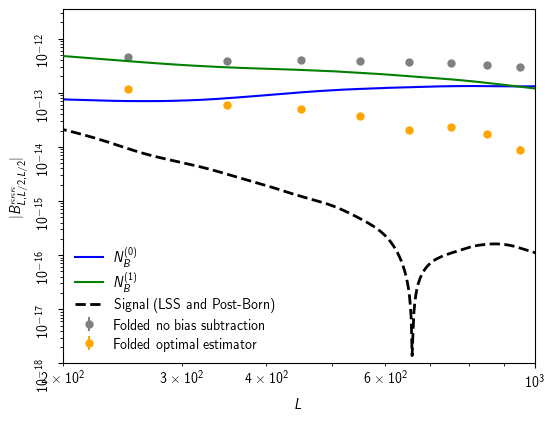

In [97]:
#This shows folded naive bispectrum with theory N0, N1 and optimal estimator
# This is still waiting for N0 to be rerun folded rlmax 3k.

#Note that the plots in thesis don't include the signal (but could easily be added)
L_naive_fld, B_naive_fld, err_naive_B_fld = np.loadtxt("/home/amb257/rds/hpc-work/kappa_bispec/bias_from_sims/no_RD_bispec/fold/average/fold_naive_Bispec.txt")


factor_N1_fld = L_N1_fld**2/2
factor_N1_fld_half = (L_N1_fld/2)**2/2
kappafactorN1fld = factor_N1_fld * factor_N1_fld_half * factor_N1_fld_half

# Interpolate N1 onto N0's L grid
from scipy.interpolate import interp1d
N1_interp_func = interp1d(L_N1_fld, -1*kappafactorN1fld*N1_fold_rlmax3k, 
                          kind='cubic', bounds_error=False, fill_value=0)
N1_on_N0_grid = N1_interp_func(fold_L_N0_num)

# Compute N0 + N1 on the common grid
N0_values = -1/128 * fold_L_N0_num**6 * N0_numerical_fold_smooth
N0_plus_N1 = N0_values + N1_on_N0_grid

for width in [12.,]:

    fig = plt.figure(figsize=(cm2inch(width), cm2inch(width*6/8.)))
    # this should be changed for making a panel of multiple figures
    ax = fig.add_subplot(111)

    zeros = np.zeros(13)
    plt.plot(fold_L_N0_num, -1/128 * fold_L_N0_num**6 * N0_numerical_fold_smooth, label='$N^{(0)}_B$', color = 'blue')    
    plt.plot(L_N1_fld, -1*kappafactorN1fld*(N1_fold_rlmax3k), label = '$N^{(1)}_B$', color = 'green' , zorder = 10)
    #plt.plot(fold_L_N0_num, N0_plus_N1, label='$N^{(0)}_B + N^{(1)}_B$', color='red', linestyle='--', linewidth=2, zorder=5)
    plt.errorbar(L_naive_fld, -1*B_naive_fld, yerr=err_naive_B_fld, color='grey', fmt ='o', label="Folded no bias subtraction", markersize=5)
    plt.errorbar(L_fd, -1*fd_opt_est, yerr=err_fd,  color='orange', fmt='o', label="Folded optimal estimator", markersize=5)  
    #Now add the signal (total)  
    plt.plot(L_fold_actual, np.abs(bl_total_fold[nonzero_fold]), label='Signal (LSS and Post-Born)', color='black', linewidth=2, linestyle='--')
    plt.yscale('log')
    plt.xscale('log')
    # Now optimal estimator result
    #plt.errorbar(L_sim, equi_opt_est,yerr = equi_err_mean, color='orange', fmt='o', label="Equilateral optimal estimator", markersize=5)
    # x axis
    plt.hlines(0, 0, 1000)
    plt.xlim([200, 1000])
    plt.ylim(1e-18,0.35e-11)
    # legend
    leg = plt.legend(frameon=True, loc='lower left')    # remove box around legend
    leg.get_frame().set_edgecolor("white")
    leg.get_frame().set_alpha(.8)

    # labels
    plt.xlabel(r"$L$"); plt.ylabel(r'$|B^{\kappa \kappa \kappa}_{L, L/2, L/2}|$')
    ax.yaxis.labelpad = 10*width/17.; ax.xaxis.labelpad = 10*width/17. # distance of axis label to tick labels

    # reduce ticks for small figures
    if width < 10:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # grid
    #plt.grid(True, which="major", axis="both")

    # reduce white space around figure
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # set vertical y axis ticklables
    for ticklabel in ax.yaxis.get_ticklabels():
        ticklabel.set_rotation("vertical")

    # save to pdf with right bounding box
    plt.savefig(f"/home/amb257/kappa_bispec/bispec_opt_est/Plots/paper_plots/figures/fold_comparison_theory_{int(width*10)}.pdf", bbox_inches='tight', pad_inches=0.02)



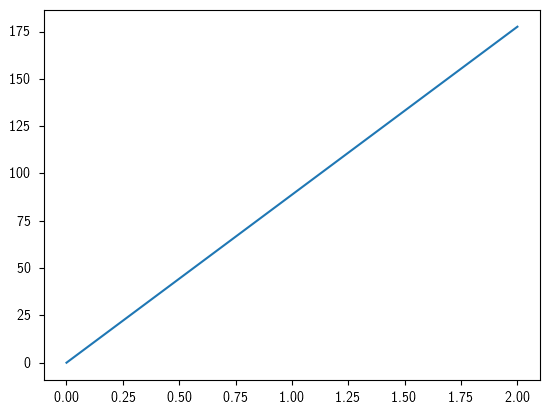

In [73]:
data = np.loadtxt("/home/amb257/kappa_bispec/CMBlens_bispectrum_noisebiases/output/N0fold_rlmax3000Lmax2000_gCl_lCl_lCl.txt", unpack='True')
L_N0_eq = data[:, 0]
N0_eq = data[:, 1]
Lfac_N0_eq = L_N0_eq**2/2
Kfac_N0_eq = Lfac_N0_eq**3
plt.plot(L_N0_eq, Kfac_N0_eq*N0_eq)

/home/amb257/jupyter_kernel_plots/lib/python3.7/site-packages/IPython/core/events.py:89: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


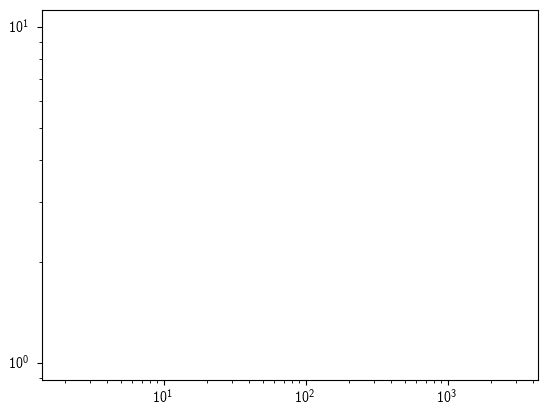

In [74]:
L_own = np.load("/home/amb257/kappa_bispec/bispec_opt_est/N0_numerical/N0_numerical_BATCHvegas/rlmax3k_FOLD_L_N0_num.npy")
N0_own = np.load("/home/amb257/kappa_bispec/bispec_opt_est/N0_numerical/N0_numerical_BATCHvegas/rlmax3k_FOLD_N0_numerical.npy")

plt.loglog(L_own, N0_own)